# L-Maze: DQN

## Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [12]:
import numpy as np
np.set_printoptions(precision=2)

In [13]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:87: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define A L-Maze Grid World 

In [28]:
from gym_classics.envs.abstract.gridworld import Gridworld

class LMazeGridworld(Gridworld):
    layout = """
|          |
|        G |
|          |
| XXXXXX   |
|      X   |
|      X   |
|      X   |
|   S  X   |
|      X   |
|          |
"""

    def __init__(self):
        super().__init__(self.layout, n_actions = 4)
        
    def _next_state(self, state, action):
        next_state = self._move(state, action)
        if self._is_blocked(next_state):
            next_state = state
        return self._clamp(next_state), 1.0

    def _reward(self, state, action, next_state):      
        return {list(self._goals)[0]: +1.0}.get(next_state, -.01)

    def _done(self, state, action, next_state):
        return next_state in self._goals  

gym.register('LMaze-v0', entry_point=LMazeGridworld)

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment LMaze-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


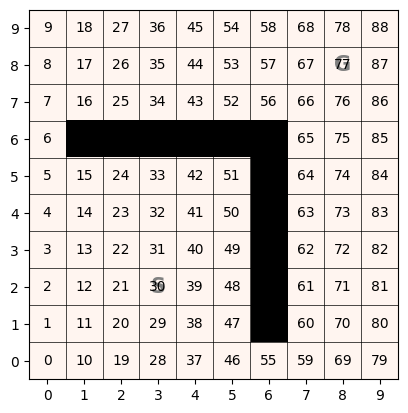

In [29]:
gym_env = gym.make('LMaze-v0')
env = gym_env.unwrapped

env.image()

In [15]:
%pip install -q stable-baselines3[extra] tqdm rich ipywidgets

Note: you may need to restart the kernel to use updated packages.


 gym_classics uses square ID's and we need to convert them into (x,y) coordinates for learning.

In [16]:
from gymnasium import ObservationWrapper
from gymnasium.spaces import Box

class XY_Wrapper(ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        
        self.the_env = env
        
        self.observation_space = Box(
            low=np.array([0,0]),
            high=np.array(env.dims),
            dtype=np.float32
        )

    def observation(self, obs):
        """
        This method is called automatically by step() and reset()
        to transform the observation.
        """
        return self.the_env.decode(obs)

In [30]:
env_states = XY_Wrapper(env)
env_states.reset()

((3, 2), {})

In [ ]:
from stable_baselines3 import DQN

log_dir = "./tb_logs/"


model = DQN(
        "MlpPolicy",
        env_states,
        gamma = 0.999,
        target_update_interval=1000,
        learning_rate=0.01,
        buffer_size=2000,
        exploration_fraction=.1,
        exploration_final_eps= .2,
        batch_size=32,
        tensorboard_log=log_dir,
        verbose = 0
    )



In [76]:
# total_timesteps (int) – The total number of samples (env steps) to train on. For comparison we use the data for 2000 episodes: 15 (opt. path length) * 2000
model.learn(total_timesteps=15 * 500, log_interval=1, progress_bar=True)

Output()

In [77]:
model.learn(total_timesteps=15 * 1000, log_interval=1, progress_bar=True, reset_num_timesteps=False)

Output()

In [47]:
from stable_baselines3.common.utils import ConstantSchedule


model.learning_rate = .01
model.exploration_schedule = ConstantSchedule(.2)

In [49]:
model.learn(total_timesteps=15 * 1000, log_interval=1, progress_bar=True, reset_num_timesteps=False)

Output()

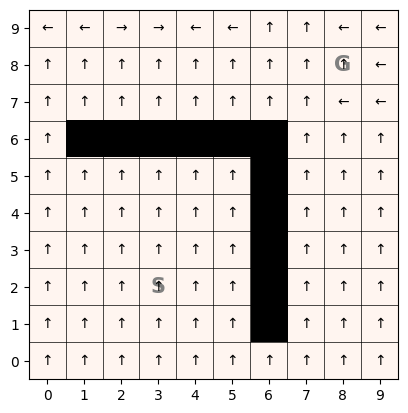

In [74]:
pol = model.predict([env.decode(s) for s in range(env.observation_space.n)])[0]
env.image(policy = pol)



&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)